In [4]:
!pip install xgboost
!pip install catboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 3.3 MB/s eta 0:00:22
   - -------------------------------------- 1.8/72.0 MB 3.2 MB/s eta 0:00:22
   - -------------------------------------- 2.4/72.0 MB 3.8 MB/s eta 0:00:19
   - -------------------------------------- 2.9/72.0 MB 3.2 MB/s eta 0:00:22
   -- ------------------------------------- 4.2/72.0 MB 3.8 MB/s eta 0:00:18
   -- ------------------------------------- 4.7/72.0 MB 3.4 MB/s eta 0:00:20
   --- ------------------------------------ 7.1/72.0 MB 4.5 MB/s eta 0:00:15
   ---- ----------------------------------- 7.9/72.0 MB 4.3 MB/s eta 0:00:15
   ----- ---------------------------------- 10.7/72.0 MB 5.3 MB/s eta 0:00:12
   ------ --------------------------------- 11.3/72.0 MB 5.0 MB/s eta 0:00:13
   -------- ------------------------------- 14.4/72.0 MB 5.8 MB/s eta 0:00:10
   -------


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached catboost-1.2.8-cp312-cp312-win_amd64.whl.metadata (1.5 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached catboost-1.2.8-cp312-cp312-win_amd64.whl (102.4 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 2.2 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.9 MB 2.9 MB/s eta 0:00:03
   ----------- ---------------------------- 2.9/9.9 MB 3.8 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 4.6 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.9 MB 5.2 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 6.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# -------------------------------
# 1. LOAD DATASET
# -------------------------------
df = pd.read_csv("1stdataset.csv")

# Make sure 'landslide' is present
if "landslide" not in df.columns:
    raise ValueError("Target column 'landslide' missing!")

# -------------------------------
# 2. ENCODE CATEGORICAL FEATURES
# -------------------------------
le = LabelEncoder()
df["stationid"] = le.fit_transform(df["stationid"])
df["dates"] = le.fit_transform(df["dates"])   # simple safe conversion

# -------------------------------
# 3. SPLIT INTO X AND y
# -------------------------------
X = df.drop("landslide", axis=1)
y = df["landslide"]

# -------------------------------
# 4. TRAIN/TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 5. XGBOOST MODEL (simple, safe)
# -------------------------------
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5
)

# -------------------------------
# 6. TRAIN MODEL
# -------------------------------
model.fit(X_train, y_train)

# -------------------------------
# 7. PREDICT
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 8. ACCURACY
# -------------------------------
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:27:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9894179894179894

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        94
           1       0.99      0.99      0.99        95

    accuracy                           0.99       189
   macro avg       0.99      0.99      0.99       189
weighted avg       0.99      0.99      0.99       189



In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# -------------------------------
# 1. LOAD DATASET
# -------------------------------
df = pd.read_csv("1stdataset.csv")

# Make sure 'landslide' is present
if "landslide" not in df.columns:
    raise ValueError("Target column 'landslide' missing!")

# -------------------------------
# 2. ENCODE CATEGORICAL FEATURES
# -------------------------------
le = LabelEncoder()
df["stationid"] = le.fit_transform(df["stationid"])
df["dates"] = le.fit_transform(df["dates"])   # simple safe conversion

# -------------------------------
# 3. SPLIT INTO X AND y
# -------------------------------
X = df.drop("landslide", axis=1)
y = df["landslide"]

# -------------------------------
# 4. TRAIN/TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 5. XGBOOST MODEL (simple, safe)
# -------------------------------
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5
)

# -------------------------------
# 6. TRAIN MODEL
# -------------------------------
model.fit(X_train, y_train)

# -------------------------------
# 7. PREDICT
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 8. ACCURACY
# -------------------------------
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


XGBoost Accuracy: 0.9894179894179894

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        94
           1       0.99      0.99      0.99        95

    accuracy                           0.99       189
   macro avg       0.99      0.99      0.99       189
weighted avg       0.99      0.99      0.99       189



C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:28:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# -------------------------------
# 1. LOAD DATASET
# -------------------------------
df = pd.read_csv("1stdataset.csv")

# Check for target column
if "landslide" not in df.columns:
    raise ValueError("Target column 'landslide' missing from dataset!")

# -------------------------------
# 2. ENCODE CATEGORICAL COLUMNS
# -------------------------------
le = LabelEncoder()

df["stationid"] = le.fit_transform(df["stationid"])
df["dates"] = le.fit_transform(df["dates"])   # simple, safe encoding

# -------------------------------
# 3. SPLIT FEATURES & TARGET
# -------------------------------
X = df.drop("landslide", axis=1)
y = df["landslide"]

# -------------------------------
# 4. SPLIT INTO TRAIN/TEST
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 5. FEATURE SCALING (REQUIRED FOR SVM)
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# 6. TRAIN SVM MODEL
# -------------------------------
model = SVC(kernel="rbf", C=10, gamma="scale")
model.fit(X_train_scaled, y_train)

# -------------------------------
# 7. PREDICT
# -------------------------------
y_pred = model.predict(X_test_scaled)

# -------------------------------
# 8. MODEL ACCURACY
# -------------------------------
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


SVM Accuracy: 0.9365079365079365

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        94
           1       0.94      0.94      0.94        95

    accuracy                           0.94       189
   macro avg       0.94      0.94      0.94       189
weighted avg       0.94      0.94      0.94       189



In [ ]:
pip install catboost


In [16]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# -------------------------------
# 1. LOAD YOUR DATASET
# -------------------------------
df = pd.read_csv("1stdataset.csv")

# Make sure target exists
if "landslide" not in df.columns:
    raise ValueError("Target column 'landslide' NOT found!")

# -------------------------------
# 2. FEATURES & TARGET
# -------------------------------
X = df.drop("landslide", axis=1)
y = df["landslide"]

# CatBoost requires categorical feature INDEX (not name!)
categorical_features = []

# If these columns exist, mark them as categorical
for col in ["stationid", "dates"]:
    if col in X.columns:
        categorical_features.append(X.columns.get_loc(col))

# -------------------------------
# 3. TRAIN-TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4. CATBOOST MODEL
# -------------------------------
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    eval_metric="Accuracy",
    verbose=False,
    random_seed=42
)

# -------------------------------
# 5. TRAIN MODEL
# -------------------------------
model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

# -------------------------------
# 6. PREDICT
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 7. ACCURACY
# -------------------------------
print("CatBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


CatBoost Accuracy: 0.9788359788359788

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        94
           1       0.97      0.99      0.98        95

    accuracy                           0.98       189
   macro avg       0.98      0.98      0.98       189
weighted avg       0.98      0.98      0.98       189



In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# -------------------------------
# 1. LOAD DATASET
# -------------------------------
df = pd.read_csv("1stdataset.csv")

# Check for target column
if "landslide" not in df.columns:
    raise ValueError("Target column 'landslide' missing!")

# -------------------------------
# 2. ENCODE CATEGORICAL COLUMNS
# -------------------------------
le = LabelEncoder()

# Encode stationid & dates
df["stationid"] = le.fit_transform(df["stationid"])
df["dates"] = le.fit_transform(df["dates"])

# -------------------------------
# 3. FEATURES & TARGET
# -------------------------------
X = df.drop("landslide", axis=1)
y = df["landslide"]

# -------------------------------
# 4. TRAIN / TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 5. RANDOM FOREST MODEL
# -------------------------------
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

# -------------------------------
# 6. TRAIN MODEL
# -------------------------------
model.fit(X_train, y_train)

# -------------------------------
# 7. PREDICT
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 8. ACCURACY
# -------------------------------
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Random Forest Accuracy: 0.9841269841269841

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98        94
           1       0.98      0.99      0.98        95

    accuracy                           0.98       189
   macro avg       0.98      0.98      0.98       189
weighted avg       0.98      0.98      0.98       189



In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("1stdataset.csv")

le = LabelEncoder()
df["stationid"] = le.fit_transform(df["stationid"])
df["dates"] = le.fit_transform(df["dates"])

X = df.drop("landslide", axis=1)
y = df["landslide"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


KNN Accuracy: 0.8835978835978836
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        94
           1       0.88      0.89      0.89        95

    accuracy                           0.88       189
   macro avg       0.88      0.88      0.88       189
weighted avg       0.88      0.88      0.88       189



In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("1stdataset.csv")

le = LabelEncoder()
df["stationid"] = le.fit_transform(df["stationid"])
df["dates"] = le.fit_transform(df["dates"])

X = df.drop("landslide", axis=1)
y = df["landslide"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("LogisticRegression:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


LogisticRegression: 0.9470899470899471
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        94
           1       0.94      0.96      0.95        95

    accuracy                           0.95       189
   macro avg       0.95      0.95      0.95       189
weighted avg       0.95      0.95      0.95       189



XGBoost Accuracy: 0.9894179894179894



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


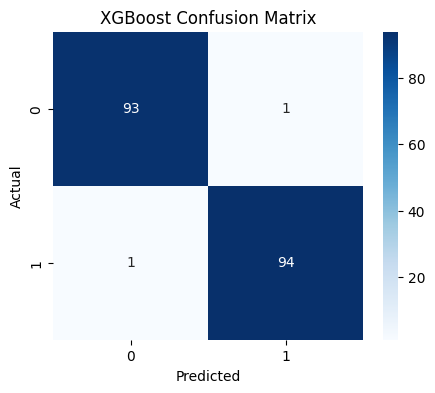

CatBoost Accuracy: 0.9841269841269841


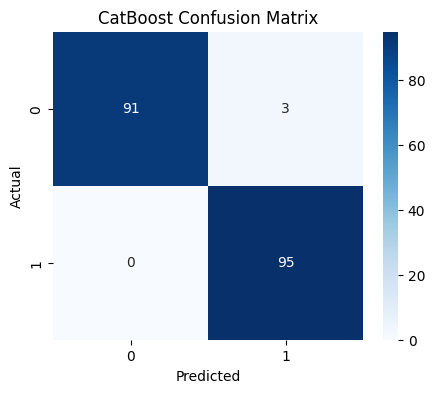

SVM Accuracy: 0.9206349206349206


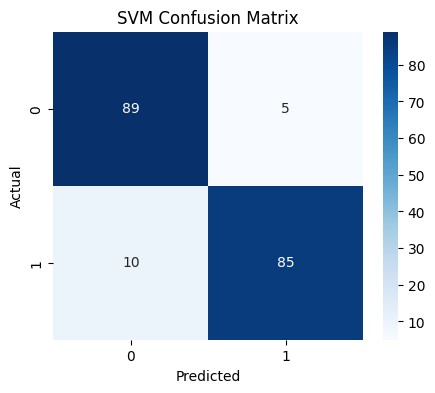

Random Forest Accuracy: 0.9841269841269841


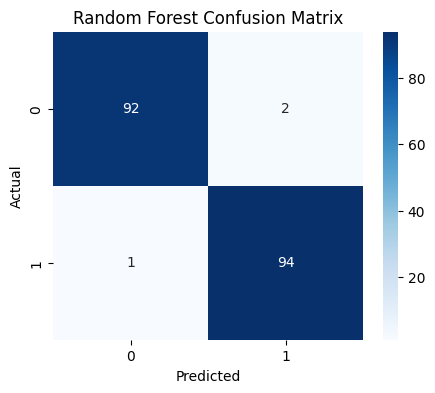

KNN Accuracy: 0.8835978835978836


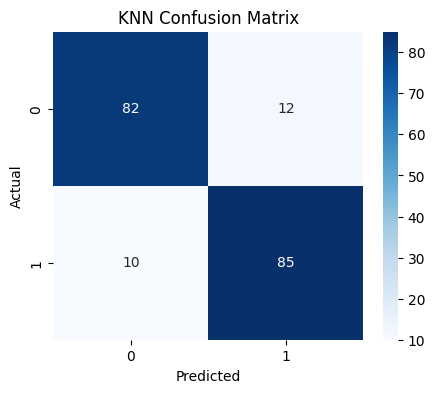

Logistic Regression Accuracy: 0.9470899470899471


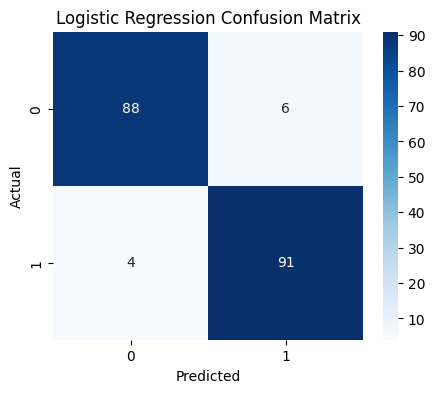

In [12]:
# Install required libraries if missing
!pip install xgboost catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# -------------------------------
# LOAD DATASET
# -------------------------------
df = pd.read_csv("1stdataset.csv")

# Encode categorical features
le = LabelEncoder()
df["stationid"] = le.fit_transform(df["stationid"])
df["dates"] = le.fit_transform(df["dates"])

# Split features and target
X = df.drop("landslide", axis=1)
y = df["landslide"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling for SVM, KNN, Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# HELPER FUNCTION: PLOT CONFUSION MATRIX
# -------------------------------
def plot_cm(cm, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# -------------------------------
# 1. XGBOOST
# -------------------------------
xgb = XGBClassifier(eval_metric="logloss")
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
cm_xgb = confusion_matrix(y_test, pred_xgb)
print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))
plot_cm(cm_xgb, "XGBoost Confusion Matrix")

# -------------------------------
# 2. CATBOOST
# -------------------------------
cat = CatBoostClassifier(verbose=0)
cat.fit(X_train, y_train)
pred_cat = cat.predict(X_test)
cm_cat = confusion_matrix(y_test, pred_cat)
print("CatBoost Accuracy:", accuracy_score(y_test, pred_cat))
plot_cm(cm_cat, "CatBoost Confusion Matrix")

# -------------------------------
# 3. SVM
# -------------------------------
svm = SVC()
svm.fit(X_train_scaled, y_train)
pred_svm = svm.predict(X_test_scaled)
cm_svm = confusion_matrix(y_test, pred_svm)
print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
plot_cm(cm_svm, "SVM Confusion Matrix")

# -------------------------------
# 4. RANDOM FOREST
# -------------------------------
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
cm_rf = confusion_matrix(y_test, pred_rf)
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
plot_cm(cm_rf, "Random Forest Confusion Matrix")

# -------------------------------
# 5. KNN
# -------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
pred_knn = knn.predict(X_test_scaled)
cm_knn = confusion_matrix(y_test, pred_knn)
print("KNN Accuracy:", accuracy_score(y_test, pred_knn))
plot_cm(cm_knn, "KNN Confusion Matrix")

# -------------------------------
# 6. LOGISTIC REGRESSION
# -------------------------------
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
cm_lr = confusion_matrix(y_test, pred_lr)
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
plot_cm(cm_lr, "Logistic Regression Confusion Matrix")


C:\Users\KIIT\AppData\Local\Temp\ipykernel_5540\2239035188.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette="mako")


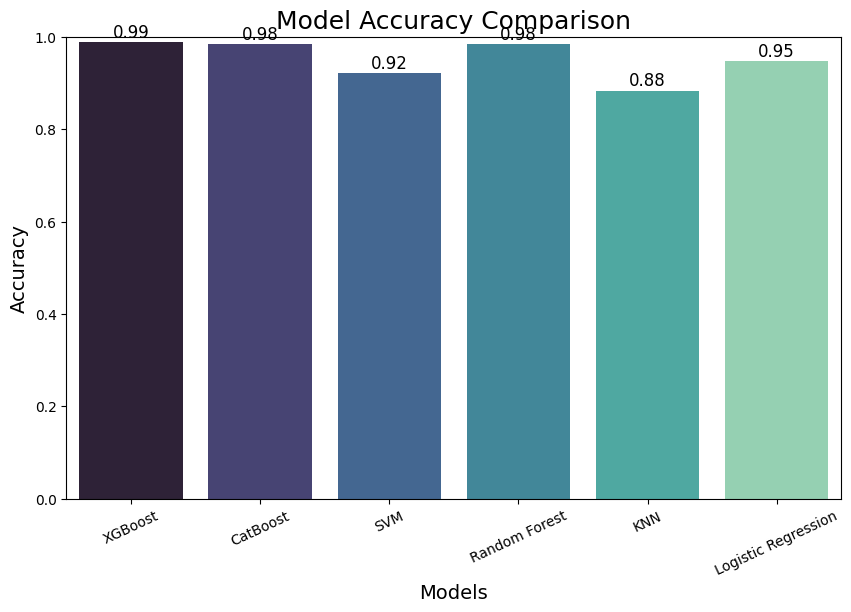

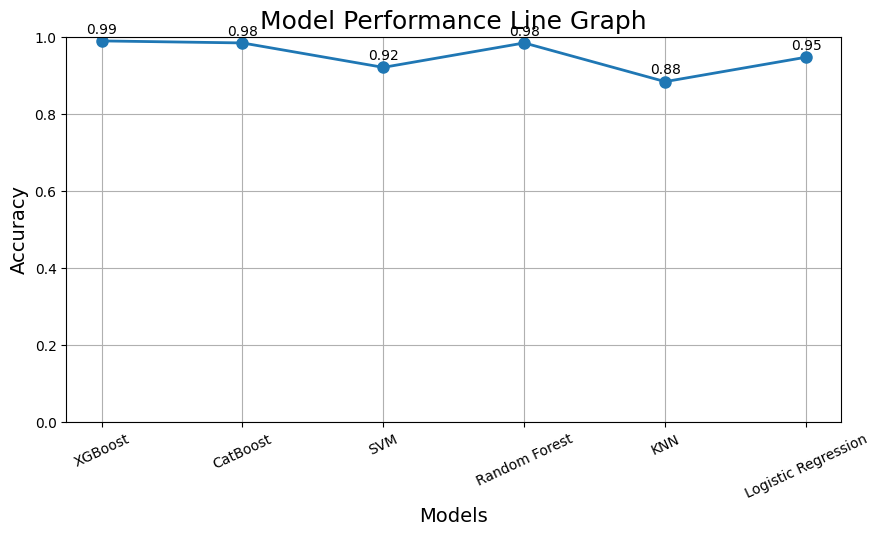

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Store model accuracies from predictions
# -------------------------------
accuracy_scores = {
    "XGBoost": accuracy_score(y_test, pred_xgb),
    "CatBoost": accuracy_score(y_test, pred_cat),
    "SVM": accuracy_score(y_test, pred_svm),
    "Random Forest": accuracy_score(y_test, pred_rf),
    "KNN": accuracy_score(y_test, pred_knn),
    "Logistic Regression": accuracy_score(y_test, pred_lr)
}

models = list(accuracy_scores.keys())
scores = list(accuracy_scores.values())

# -------------------------------
# BAR CHART (ACCURACY COMPARISON)
# -------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=scores, palette="mako")

plt.title("Model Accuracy Comparison", fontsize=18)
plt.ylabel("Accuracy", fontsize=14)
plt.xlabel("Models", fontsize=14)
plt.ylim(0, 1)

# Label values on bars
for i, value in enumerate(scores):
    plt.text(i, value + 0.01, f"{value:.2f}", ha='center', fontsize=12)

plt.xticks(rotation=25)
plt.show()

# -------------------------------
# LINE GRAPH (OPTIONAL ADVANCED VISUAL)
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(models, scores, marker='o', linestyle='-', linewidth=2, markersize=8)

plt.title("Model Performance Line Graph", fontsize=18)
plt.ylabel("Accuracy", fontsize=14)
plt.xlabel("Models", fontsize=14)
plt.ylim(0, 1)

# Label each point
for i, value in enumerate(scores):
    plt.text(models[i], value + 0.02, f"{value:.2f}", ha='center')

plt.grid(True)
plt.xticks(rotation=25)
plt.show()


In [24]:
# ============================================
# FINAL WORKING MODEL TRAIN + SAVE PIPELINES
# ============================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
import joblib

# 1️⃣ LOAD DATA
df = pd.read_csv("1stdataset.csv")

# 2️⃣ CREATE LABEL ENCODERS (fix for your error)
le_station = LabelEncoder()
le_dates = LabelEncoder()

df["stationid_enc"] = le_station.fit_transform(df["stationid"])
df["dates_enc"] = le_dates.fit_transform(df["dates"])

df = df.drop(columns=["stationid", "dates"])

# 3️⃣ FEATURE SPLIT
X = df.drop("landslide", axis=1)
y = df["landslide"]

# 4️⃣ TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5️⃣ SCALE DATA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6️⃣ TRAIN ALL MODELS + STORE THEM PROPERLY
lr = LogisticRegression(max_iter=500)
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel="rbf", C=10, gamma="scale", probability=True)
rf = RandomForestClassifier(n_estimators=300, random_state=42)

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1
)

cat = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    verbose=False
)

models = {
    "Logistic Regression": lr,
    "K-Nearest Neighbors": knn,
    "Support Vector Machine": svm,
    "Random Forest": rf,
    "XGBoost": xgb,
    "CatBoost": cat
}

# 7️⃣ TRAIN & SAVE PIPELINES
filename_map = {
    "Logistic Regression": "logistic_pipeline.pkl",
    "K-Nearest Neighbors": "knn_pipeline.pkl",
    "Support Vector Machine": "svm_pipeline.pkl",
    "Random Forest": "rf_pipeline.pkl",
    "XGBoost": "xgb_pipeline.pkl",
    "CatBoost": "catboost_pipeline.pkl"
}

for name, model in models.items():

    print(f"\nTraining {name} ...")
    model.fit(X_train_scaled, y_train)

    pipeline = {
        "model": model,
        "scaler": scaler,
        "le_station": le_station,
        "le_dates": le_dates,
        "feature_columns": X.columns.tolist()
    }

    filename = filename_map[name]
    joblib.dump(pipeline, filename)
    print(f"Saved {filename}")



Training Logistic Regression ...
Saved logistic_pipeline.pkl

Training K-Nearest Neighbors ...
Saved knn_pipeline.pkl

Training Support Vector Machine ...
Saved svm_pipeline.pkl

Training Random Forest ...
Saved rf_pipeline.pkl

Training XGBoost ...
Saved xgb_pipeline.pkl

Training CatBoost ...


C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:44:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved catboost_pipeline.pkl


In [26]:
pip install streamlit joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
